In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

import numpy as np

manualSeed = 999
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True)

# Data

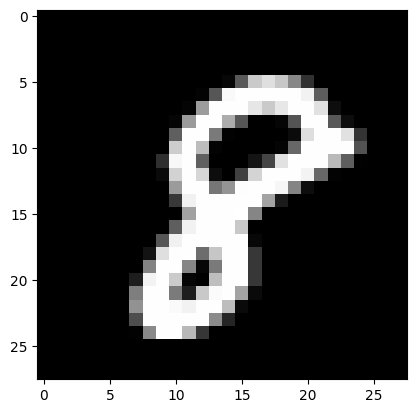

Labels:     8


In [2]:
from preprocessing.mnist import train_valid_test, display_sample, imshow

batch_size = 1
n_train = 100  # samples per class
n_valid = 400
classes = range(10)

trainloader, validloader, testloader = train_valid_test(classes, batch_size=batch_size, n_train=n_train, n_valid=n_valid)
display_sample(trainloader)

# Model Init

In [3]:
from models.polynet import PolynomialNet
from models.switchable import Switchable
from train.eval import num_params
from train.config import device

arch = PolynomialNet

model = Switchable.from_model(arch(len(classes))).to(device)
print(f"{model.__class__.__name__} has {num_params(model)} parameters")

Switchable has 46994 parameters


# Training

In [4]:
from train.train import train
from train.validate import Validate

criterion = nn.CrossEntropyLoss()

In [5]:
num_models = 2
models: list[nn.Module] = []
validates: list[Validate] = []

for i in range(num_models):
    model.switch(0)
    (best_acc, best_model), validate = train(
        model, trainloader, validloader, criterion, 
        lr=0.002, epochs=30,
        val_gap=100, verbose=True
    )

    models.append((best_acc, best_model))
    validates.append(validate)

[1, 100] loss: 2.427
tensor([-0.5101,  0.0692, -0.3443, -0.0376,  0.1585, -0.4903,  0.2437,  0.0357,
        -0.3765, -0.5177], grad_fn=<SelectBackward0>) tensor(3)
Validation Accuracy: 0.100
[1, 200] loss: 2.315
tensor([-0.5215, -0.0600, -0.1418, -0.1372, -0.4113, -0.2614,  0.1374,  0.1855,
        -0.1215, -0.4789], grad_fn=<SelectBackward0>) tensor(6)
Validation Accuracy: 0.100
[1, 300] loss: 2.274
tensor([-1.6308,  1.9704,  0.6638, -0.2091, -0.2953, -1.6655, -0.2201,  0.9041,
        -0.9446, -0.2743], grad_fn=<SelectBackward0>) tensor(9)
Validation Accuracy: 0.253
[1, 400] loss: 2.189
tensor([-1.1267,  1.3792,  0.1525, -0.5258, -0.3731, -1.2752, -0.3560,  0.1871,
        -0.3212,  0.2264], grad_fn=<SelectBackward0>) tensor(1)
Validation Accuracy: 0.218
[1, 500] loss: 2.006
tensor([-0.7083, -0.3126,  0.3036,  0.3654, -0.5310, -0.3446,  0.0083, -0.4178,
        -0.2570, -0.2918], grad_fn=<SelectBackward0>) tensor(8)
Validation Accuracy: 0.365
[1, 600] loss: 1.988
tensor([-0.1792, -1

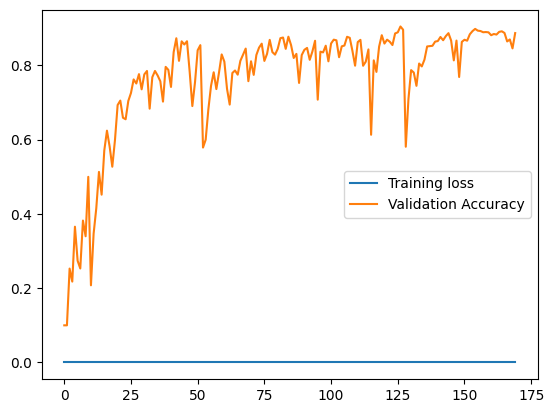

In [6]:
validates[0].show_history()

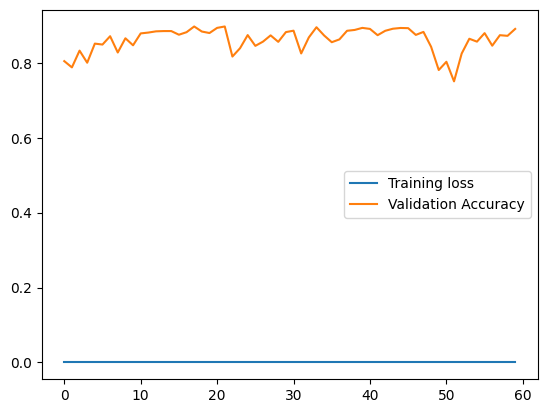

In [7]:
validates[1].show_history()

In [8]:
PATH = './trained_models/quadnet.pth'
torch.save(models[0][1].state_dict(), PATH)

# Model Evaluation

Accuracy of the model 0 on the test images with quantum layer: 91.66101694915254 %
Incorrectly predicted images


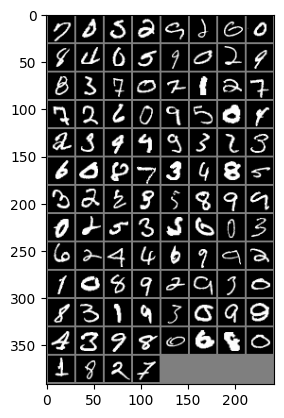

In [9]:
from train.eval import get_acc

acc, errors = get_acc(models[0][1], testloader)
print(f'Accuracy of the model 0 on the test images with quantum layer: {100 * acc} %')

print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors[:100]))

Accuracy of the model 1 on the test images with quantum layer: 91.2 %
Incorrectly predicted images


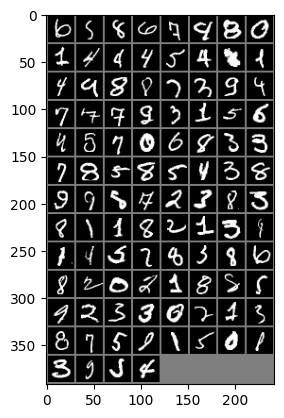

In [10]:
from train.eval import get_acc

acc, errors = get_acc(models[1][1], testloader)
print(f'Accuracy of the model 1 on the test images with quantum layer: {100 * acc} %')

print("Incorrectly predicted images")
imshow(torchvision.utils.make_grid(errors[:100]))